# Koduppgift kapitel 6

## Uppgift 7

   median_income  latitude  longitude
0         8.3252     37.88    -122.23
1         8.3014     37.86    -122.22
2         7.2574     37.85    -122.24
3         5.6431     37.85    -122.25
4         3.8462     37.85    -122.25
   median_income  latitude  longitude Cluster
0         8.3252     37.88    -122.23       1
1         8.3014     37.86    -122.22       1
2         7.2574     37.85    -122.24       1
3         5.6431     37.85    -122.25       1
4         3.8462     37.85    -122.25       2


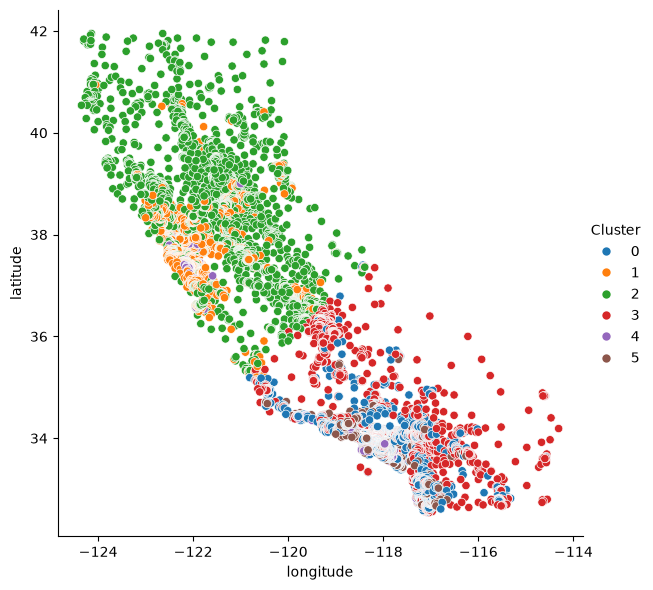

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns 
from sklearn.cluster import KMeans 

df = pd.read_csv("./dataset/housing.csv") 

X = df.loc[:, ["median_income", "latitude", "longitude"]] 
print(X.head()) 
kmeans = KMeans(n_clusters=6) 
X["Cluster"] = kmeans.fit_predict(X) 
X["Cluster"] = X["Cluster"].astype("category")

print(X.head())

sns.relplot(
    x='longitude', y='latitude', hue='Cluster', data=X, height=6
)


**A)** Det koden gör är att den läser in datasetet skapar vi en X med 3 kolumer i sig. vi kör sen en Kmean för att skapa en klustring med 6 st kluster i sig som vi kan jobba med. Vi tar sen och tränar X['cluster'] på datan, och sen renderar vi ut den.

**B)** Om jag bara utgår vad datasetet innehåller (s.70) så hade jag velat ha kluster som innehöll: total_rooms, total_rooms, median_house_value. Detta känns som det hade varit lättast om vi har vinklen om ätt vi sysslar med husförsäljning.

Då hade man även kunna lägga till hur långt man har till beach osv. 

och hade jag försökt sälja hus hade jag nog velat ha house prices med, men man kan inte få allt. med det är det jag hade velat göra kluster på. 

**C)**

In [3]:
df = pd.read_csv("./dataset/housing.csv") 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


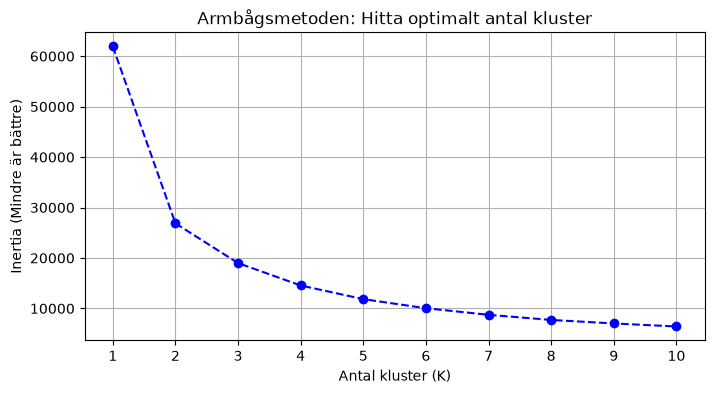

In [ ]:
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("./dataset/housing.csv") 
X = df.loc[:, ["median_income", "latitude", "longitude"]] 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia, marker='o', linestyle='--', color='b')
plt.title('Armbågsmetoden')
plt.xlabel('Antal kluster (K)')
plt.ylabel('Inertia (Mindre är bättre)')
plt.xticks(k_values)
plt.grid(True)
plt.show() 


När vi kollar datasetet med olika kluster och använder "armbågsmetoden" så ser vi att det optimala antal kluster ligger på 3-5 st. eftersom 4 ligger ganska mycket i mitten av "armbågen" så hade jag nog kört på den.

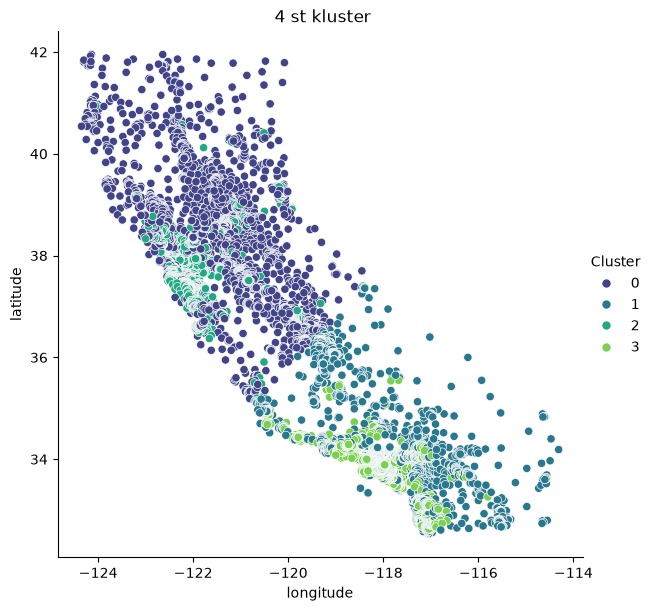

In [7]:
optimal_k = 4  
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)


X["Cluster"] = final_kmeans.fit_predict(X_scaled) 
X["Cluster"] = X["Cluster"].astype("category")

sns.relplot(
    x='longitude', 
    y='latitude', 
    hue='Cluster', 
    data=X, 
    height=6,
    palette='viridis' 
)
plt.title(f' {optimal_k} st kluster')
plt.show()

**D)**

## Uppgift 8

## Uppgift 9